In [1]:
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    recall_score
)
from sklearn.preprocessing import LabelEncoder

In [2]:
X_train = pd.read_csv("X_train_processed.csv")
X_test = pd.read_csv("X_test_processed.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

In [3]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

le.classes_

array(['At_Risk', 'Malnourished', 'Normal'], dtype=object)

In [4]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_enc)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

class_weights

array([1.1037037 , 1.64558233, 0.6728243 ])

In [5]:
class_weights_dict = {
    int(cls): weight for cls, weight in zip(classes, class_weights)
}
class_weights_dict

{0: np.float64(1.1037037037037036),
 1: np.float64(1.645582329317269),
 2: np.float64(0.672824302134647)}

In [6]:
cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    class_weights=class_weights_dict,
    eval_metric="TotalF1",
    random_seed=42,
    verbose=False
)

cat.fit(X_train, y_train_enc)

In [7]:
y_pred_cat = cat.predict(X_test).astype(int).ravel()
y_pred_cat_labels = le.inverse_transform(y_pred_cat)

print("Accuracy:", accuracy_score(y_test, y_pred_cat_labels))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_cat_labels))

Accuracy: 0.3524390243902439

Classification Report:
               precision    recall  f1-score   support

     At_Risk       0.25      0.26      0.26       248
Malnourished       0.20      0.21      0.21       166
      Normal       0.49      0.47      0.48       406

    accuracy                           0.35       820
   macro avg       0.31      0.31      0.31       820
weighted avg       0.36      0.35      0.36       820



In [8]:
print("Recall (At_Risk):",
      recall_score(y_test, y_pred_cat_labels,
                   labels=["At_Risk"], average=None))

print("Recall (Malnourished):",
      recall_score(y_test, y_pred_cat_labels,
                   labels=["Malnourished"], average=None))

Recall (At_Risk): [0.26209677]
Recall (Malnourished): [0.21084337]


In [9]:
confusion_matrix(y_test, y_pred_cat_labels)

array([[ 65,  61, 122],
       [ 58,  35,  73],
       [138,  79, 189]])

In [10]:
import shap

In [11]:
explainer = shap.TreeExplainer(cat)

In [12]:
shap_values = explainer.shap_values(X_test)

In [13]:
type(shap_values)
# len(shap_values)

numpy.ndarray

In [14]:
len(shap_values)

820

In [15]:
le.classes_

array(['At_Risk', 'Malnourished', 'Normal'], dtype=object)

In [16]:
shap_values.shape

(820, 19, 3)

In [17]:
shap_values_no_bias = shap_values[:, :-1, :]

In [18]:
shap_malnourished = shap_values_no_bias[:, :, 1]

In [19]:
shap_values.shape

(820, 19, 3)

In [20]:
shap_malnourished.shape

(820, 18)

In [21]:
X_test.shape
len(X_test.columns)

19

In [22]:
set(X_test.columns)

{'age_months',
 'anemia',
 'diarrhea',
 'gender_Female',
 'gender_Male',
 'height_cm',
 'household_wealth_index',
 'malaria',
 'mother_education',
 'overweight',
 'region_Addis Ababa',
 'region_Amhara',
 'region_Oromia',
 'region_SNNPR',
 'region_Tigray',
 'stunting',
 'tb',
 'underweight',
 'weight_kg'}

In [23]:
cat.feature_names_

['age_months',
 'height_cm',
 'weight_kg',
 'gender_Female',
 'gender_Male',
 'region_Addis Ababa',
 'region_Amhara',
 'region_Oromia',
 'region_SNNPR',
 'region_Tigray',
 'mother_education',
 'household_wealth_index',
 'stunting',
 'underweight',
 'overweight',
 'anemia',
 'malaria',
 'diarrhea',
 'tb']

In [24]:
extra_cols = set(X_test.columns) - set(cat.feature_names_)
extra_cols

set()

In [25]:
X_test_aligned = X_test[cat.feature_names_]

In [26]:
X_test_aligned.shape

(820, 19)

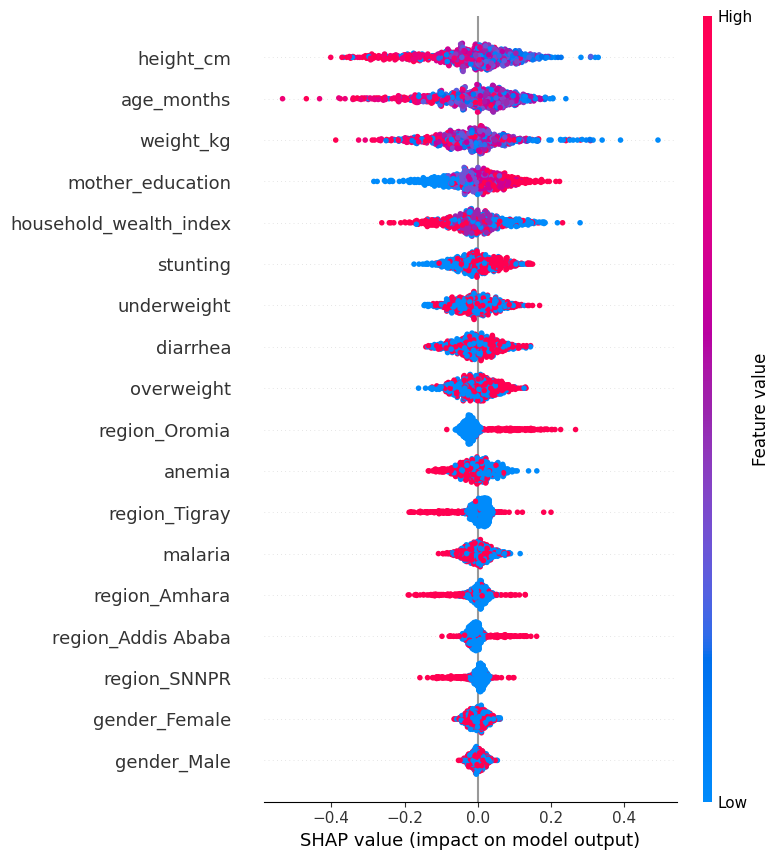

In [27]:
X_test_shap = X_test.iloc[:, :shap_malnourished.shape[1]]

shap.summary_plot(
    shap_malnourished,
    X_test_shap.values,
    feature_names=X_test_shap.columns
)

In [28]:
shap_at_risk = shap_values_no_bias[:, :, 0]
shap_at_risk.shape


(820, 18)

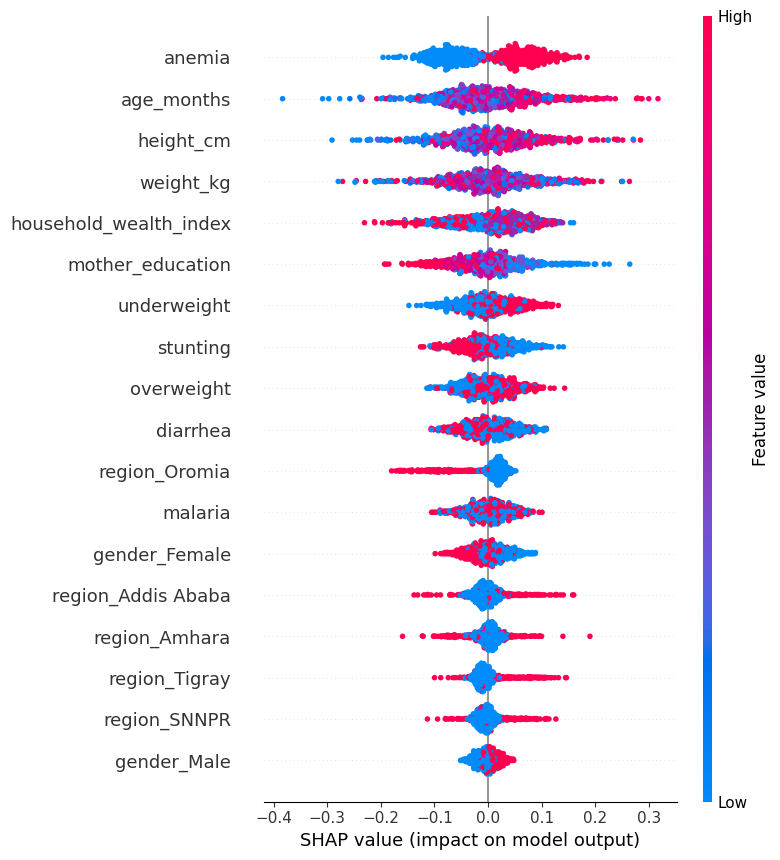

In [29]:
X_test_shap = X_test.iloc[:, :shap_at_risk.shape[1]]
shap.summary_plot(
    shap_at_risk,
    X_test_shap.values,
    feature_names=X_test_shap.columns
)


In [30]:
import shap
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_malnourished,
    X_test_shap.values,
    feature_names=X_test_shap.columns,
    show=False
)

plt.tight_layout()
plt.savefig(
    "shap_global_malnourished.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

In [31]:
shap.summary_plot(
    shap_at_risk,
    X_test_shap.values,
    feature_names=X_test_shap.columns,
    show=False
)

plt.tight_layout()
plt.savefig(
    "shap_global_at_risk.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

In [32]:
shap.summary_plot(
    shap_malnourished,
    X_test_shap.values,
    feature_names=X_test_shap.columns,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(
    "shap_risk_factors_malnourished.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

In [33]:
idx = np.where(y_pred_cat_labels == "Malnourished")[0][0]

In [34]:
shap.plots.bar(
    shap.Explanation(
        values=shap_malnourished[idx],
        data=X_test_shap.iloc[idx],
        feature_names=X_test_shap.columns
    ),
    show=False
)

plt.tight_layout()
plt.savefig(
    "shap_local_child_malnourished.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

In [35]:
shap.initjs()

force_plot = shap.force_plot(
    explainer.expected_value[1],
    shap_malnourished[idx],
    X_test_shap.iloc[idx],
    feature_names=X_test_shap.columns
)

In [36]:
shap.save_html(
    "shap_force_child_malnourished.html",
    force_plot
)

In [37]:
cat

In [38]:
cat.save_model("catboost_malnutrition_model.cbm")

In [39]:
locals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'CatBoostClassifier', 'accuracy_score', 'classification_report', 'confusion_matrix', 'recall_score', 'LabelEncoder', '_i2', 'X_train', 'X_test', 'y_train', 'y_test', '_i3', 'le', 'y_train_enc', 'y_test_enc', '_3', '_i4', 'compute_class_weight', 'classes', 'class_weights', '_4', '_i5', 'class_weights_dict', '_5', '_i6', 'cat', '_6', '_i7', 'y_pred_cat', 'y_pred_cat_labels', '_i8', '_i9', '_9', '_i10', 'shap', '_i11', 'explainer', '_i12', 'shap_values', '_i13', '_13', '_i14', '_14', '_i15', '_15', '_i16', '_16', '_i17', 'shap_values_no_bias', '_i18', 'shap_malnourished', '_i19', '_19', '_i20', '_20', '_i21', '_21', '_i22', '_22', '_i23', '_23', '_i24', 'extra_cols', '_24', '_i25', 'X_test_aligned', '_i26', '_26', '_i27', 'X_test_shap', '_i2

In [40]:
!!pip install imbalanced-learn

['Collecting imbalanced-learn',
 '  Downloading imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)',
 'Requirement already satisfied: numpy<3,>=1.25.2 in c:\\users\\bluebrand_pvt_ltd\\documents\\fl\\local-ml-client\\project_private\\.venv\\lib\\site-packages (from imbalanced-learn) (2.3.5)',
 'Requirement already satisfied: scipy<2,>=1.11.4 in c:\\users\\bluebrand_pvt_ltd\\documents\\fl\\local-ml-client\\project_private\\.venv\\lib\\site-packages (from imbalanced-learn) (1.16.3)',
 'Requirement already satisfied: scikit-learn<2,>=1.4.2 in c:\\users\\bluebrand_pvt_ltd\\documents\\fl\\local-ml-client\\project_private\\.venv\\lib\\site-packages (from imbalanced-learn) (1.7.2)',
 'Collecting sklearn-compat<0.2,>=0.1.5 (from imbalanced-learn)',
 '  Downloading sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)',
 'Requirement already satisfied: joblib<2,>=1.2.0 in c:\\users\\bluebrand_pvt_ltd\\documents\\fl\\local-ml-client\\project_private\\.venv\\lib\\site-packages (from imbal

In [41]:
from imblearn.over_sampling import SMOTE

In [42]:
smote = SMOTE(
    sampling_strategy="auto",
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train, y_train_enc
)

In [43]:
import numpy as np

np.unique(y_train_smote, return_counts=True)

(array([0, 1, 2]), array([1624, 1624, 1624]))

In [44]:
cat_smote = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=42,
    verbose=False
)

cat_smote.fit(X_train_smote, y_train_smote)

In [45]:
y_pred_smote = cat_smote.predict(X_test).astype(int).ravel()
y_pred_smote_labels = le.inverse_transform(y_pred_smote)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_smote_labels))
print(classification_report(y_test, y_pred_smote_labels))

Accuracy: 0.424390243902439
              precision    recall  f1-score   support

     At_Risk       0.28      0.20      0.23       248
Malnourished       0.24      0.08      0.12       166
      Normal       0.49      0.70      0.58       406

    accuracy                           0.42       820
   macro avg       0.34      0.33      0.31       820
weighted avg       0.37      0.42      0.38       820

